In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [72]:
df=pd.read_csv("../data/calories.csv")
df

,user_id,age,gender,bmi,active_hours,workout_hours,workout_type,calories_burnt
0,1,20.0,Female,30.368669,5.254338,1.219884,Mixed,1573.097315
1,2,46.0,Male,31.475678,5.584941,3.308829,Strength,2035.016593
2,3,32.0,Male,21.554478,10.561181,0.000000,NaN,1771.662910
3,4,56.0,Male,27.443454,10.038466,1.593872,Cardio,2097.055515
4,5,28.0,Male,27.831313,6.652297,0.000000,NaN,1443.542811
...,...,...,...,...,...,...,...,...
14995,14996,32.0,Female,22.837903,6.960810,1.057876,NaN,1424.460012
14996,14997,63.0,Female,23.664671,7.878593,2.193699,Cardio,1963.245860
14997,14998,57.0,Female,20.768065,3.807185,0.920110,Cardio,1272.421167
14998,14999,32.0,Male,22.456105,9.387830,2.381580,NaN,1663.344043


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         15000 non-null  int64  
 1   age             14982 non-null  float64
 2   gender          15000 non-null  object 
 3   bmi             14980 non-null  float64
 4   active_hours    14976 non-null  float64
 5   workout_hours   14978 non-null  float64
 6   workout_type    8332 non-null   object 
 7   calories_burnt  15000 non-null  float64
dtypes: float64(5), int64(1), object(2)
memory usage: 937.6+ KB


In [74]:
df.describe()

,user_id,age,bmi,active_hours,workout_hours,calories_burnt
count,15000.000000,14982.000000,14980.000000,14976.000000,14978.000000,15000.000000
mean,7500.500000,41.177346,25.027650,7.939675,1.111525,1716.767677
std,4330.271354,13.537454,3.999768,2.219373,1.092277,294.078878
min,1.000000,18.000000,7.981409,-11.919711,-3.560022,581.639388
25%,3750.750000,29.000000,22.335430,6.626565,0.000000,1505.914111
50%,7500.500000,41.000000,25.046474,7.974012,1.053870,1695.842207
75%,11250.250000,53.000000,27.737444,9.364653,1.922138,1909.039725
max,15000.000000,64.000000,39.272395,16.252740,5.465399,2909.961695


In [83]:
df.isnull().sum()

user_id           0
age               0
gender            0
bmi               0
active_hours      0
workout_hours     0
workout_type      0
calories_burnt    0
dtype: int64

<Axes: xlabel='calories_burnt', ylabel='Count'>

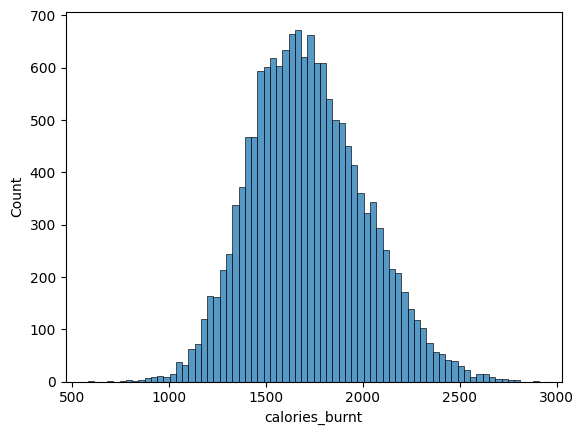

In [76]:
sns.histplot(df["calories_burnt"])

<Axes: >

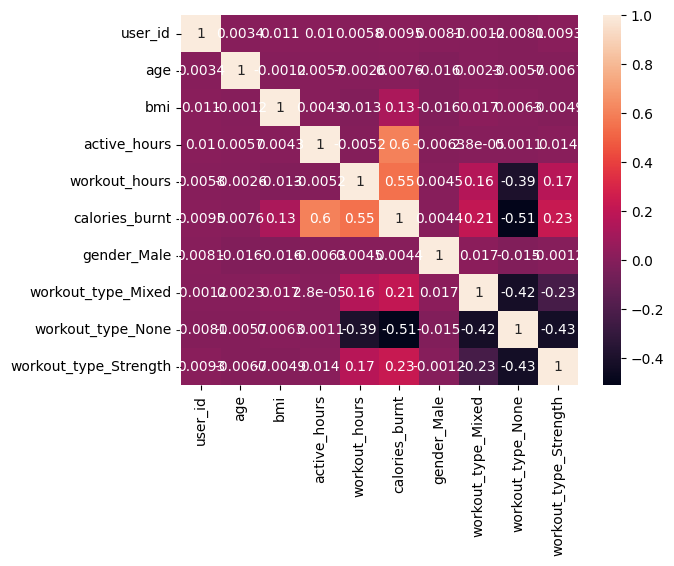

In [108]:
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True)

In [145]:
# Remove identifiers and impute missing values before encoding/splitting

if "user_id" in df.columns:
    df = df.drop("user_id", axis=1)

if "workout_type" in df.columns:
    df["workout_type"] = df["workout_type"].fillna("None")

for col in ["age", "bmi", "active_hours", "workout_hours"]:
    if col in df.columns:
        df[col].fillna(df[col].median(), inplace=True)

C:\Users\athar\AppData\Local\Temp\ipykernel_26876\1795549268.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\athar\AppData\Local\Temp\ipykernel_26876\1795549268.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

In [82]:
df["workout_type"]=df["workout_type"].fillna("None")

In [ ]:
df

,user_id,age,gender,bmi,active_hours,workout_hours,workout_type,calories_burnt
0,1,20.0,Female,30.368669,5.254338,1.219884,Mixed,1573.097315
1,2,46.0,Male,31.475678,5.584941,3.308829,Strength,2035.016593
2,3,32.0,Male,21.554478,10.561181,0.000000,None,1771.662910
3,4,56.0,Male,27.443454,10.038466,1.593872,Cardio,2097.055515
4,5,28.0,Male,27.831313,6.652297,0.000000,None,1443.542811
...,...,...,...,...,...,...,...,...
14995,14996,32.0,Female,22.837903,6.960810,1.057876,None,1424.460012
14996,14997,63.0,Female,23.664671,7.878593,2.193699,Cardio,1963.245860
14997,14998,57.0,Female,20.768065,3.807185,0.920110,Cardio,1272.421167
14998,14999,32.0,Male,22.456105,9.387830,2.381580,None,1663.344043


In [110]:
# Encode categorical variables and ensure remaining features are numeric
from sklearn.preprocessing import OneHotEncoder

categorical_cols = [c for c in ["gender", "workout_type"] if c in df.columns]
if categorical_cols:
    encoder = OneHotEncoder(sparse_output=False, drop="first", dtype=float)
    encoded = encoder.fit_transform(df[categorical_cols])
    encoded_df = pd.DataFrame(
        encoded,
        columns=encoder.get_feature_names_out(categorical_cols),
        index=df.index,
    )
    df = pd.concat([df.drop(categorical_cols, axis=1), encoded_df], axis=1)
else:
    print("No categorical columns found for encoding; assuming already encoded.")

# Drop any remaining non-numeric columns so sklearn modeling won't fail
non_numeric = df.select_dtypes(exclude="number").columns.tolist()
if non_numeric:
    print(f"Dropping non-numeric columns: {non_numeric}")
    df = df.drop(non_numeric, axis=1)

No categorical columns found for encoding; assuming already encoded.


In [114]:
# Categorical encoding handled earlier; no action needed here.

In [97]:
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_cols))

In [87]:
df = df.drop(categorical_cols, axis=1)

In [88]:
df = pd.concat([df, encoded_df], axis=1)

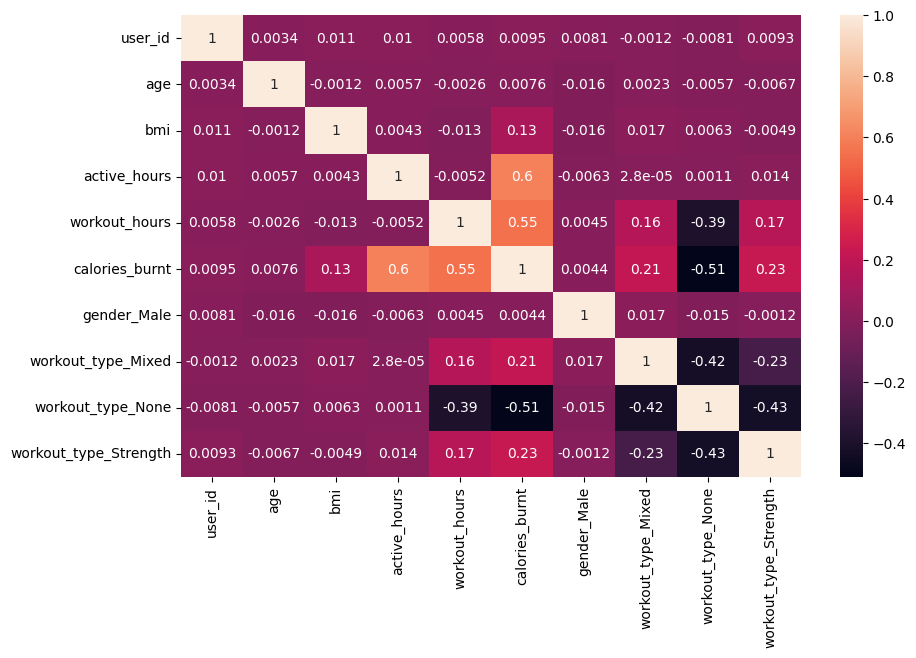

In [89]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True)
plt.show()

In [142]:
x=df.drop("calories_burnt",axis="columns")
y=df["calories_burnt"]

In [91]:
from sklearn.model_selection import train_test_split

In [112]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [80]:
# Missing values are imputed earlier; this cell is intentionally left as a no-op.

C:\Users\athar\AppData\Local\Temp\ipykernel_26876\3131514462.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["bmi"].fillna(df["bmi"].median(), inplace=True)
C:\Users\athar\AppData\Local\Temp\ipykernel_26876\3131514462.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

In [92]:
from sklearn.linear_model import LinearRegression

In [93]:
model = LinearRegression()

In [107]:
# Check available columns to debug KeyError
print(df.columns.tolist())
print(df.head())

['user_id', 'age', 'bmi', 'active_hours', 'workout_hours', 'calories_burnt', 'gender_Male', 'workout_type_Mixed', 'workout_type_None', 'workout_type_Strength']
   user_id   age        bmi  active_hours  workout_hours  calories_burnt  \
0        1  20.0  30.368669      5.254338       1.219884     1573.097315   
1        2  46.0  31.475678      5.584941       3.308829     2035.016593   
2        3  32.0  21.554478     10.561181       0.000000     1771.662910   
3        4  56.0  27.443454     10.038466       1.593872     2097.055515   
4        5  28.0  27.831313      6.652297       0.000000     1443.542811   

   gender_Male  workout_type_Mixed  workout_type_None  workout_type_Strength  
0          0.0                 1.0                0.0                    0.0  
1          1.0                 0.0                0.0                    1.0  
2          1.0                 0.0                1.0                    0.0  
3          1.0                 0.0                0.0              

In [102]:
X_train.dtypes

user_id            int64
age              float64
gender            object
bmi              float64
active_hours     float64
workout_hours    float64
workout_type      object
dtype: object

In [113]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [117]:
predictions = model.predict(X_test)
predictions

array([1943.69436613, 1525.3276146 , 1603.2315096 , ..., 1804.32928666,
       1549.31286184, 1495.83197719], shape=(3000,))

In [119]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 17940.49292189354
R2 Score: 0.7877266769934466


In [121]:
model.score(X_test,y_test)

0.7877266769934466

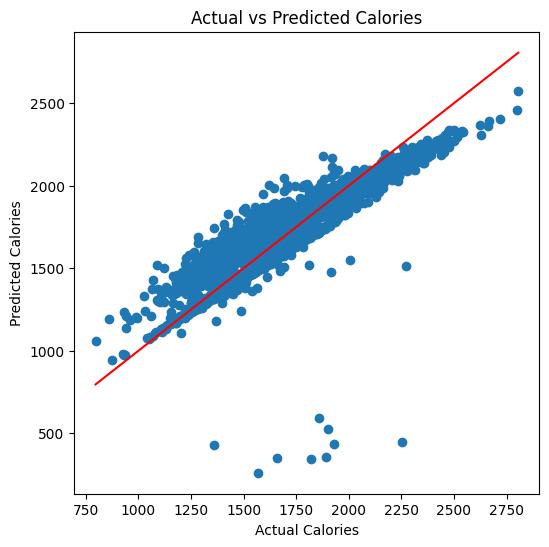

In [122]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, predictions)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.title("Actual vs Predicted Calories")

plt.show()

In [123]:
from sklearn.ensemble import RandomForestRegressor

In [124]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [128]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [129]:
rf_predictions = rf_model.predict(X_test)

In [130]:
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest MSE:", rf_mse)
print("Random Forest R2:", rf_r2)

Random Forest MSE: 699.427611084103
Random Forest R2: 0.9917243175060049


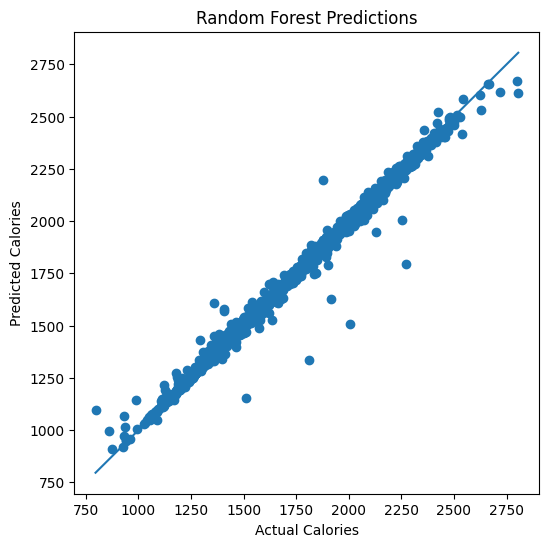

In [131]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, rf_predictions)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
)

plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.title("Random Forest Predictions")

plt.show()

In [133]:
importance = rf_model.feature_importances_
features = x.columns


In [134]:
importance_df = pd.DataFrame({
    "feature": features,
    "importance": importance
})

In [135]:
importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print(importance_df)

                 feature  importance
3           active_hours    0.459800
7      workout_type_None    0.261885
4          workout_hours    0.259129
2                    bmi    0.017119
0                user_id    0.000918
1                    age    0.000759
5            gender_Male    0.000174
8  workout_type_Strength    0.000110
6     workout_type_Mixed    0.000107


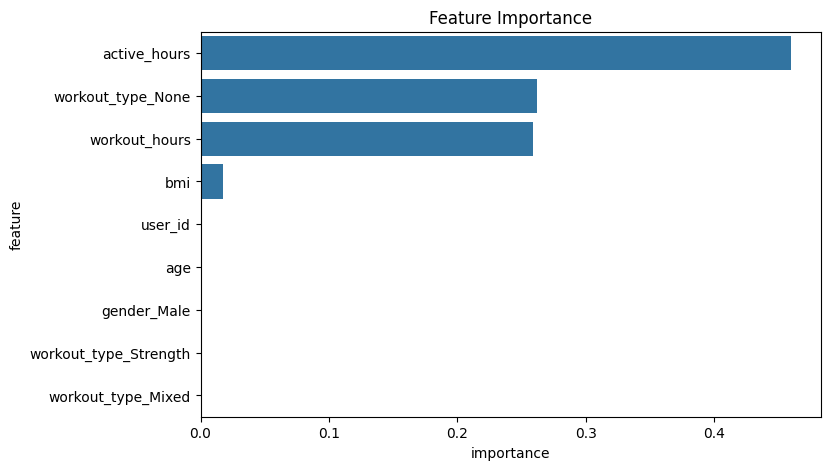

In [136]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="importance",
    y="feature",
    data=importance_df
)

plt.title("Feature Importance")
plt.show()

In [137]:
import pickle

In [138]:
with open("../model/calorie_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

In [140]:
with open("../model/calorie_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

In [141]:
test_prediction = loaded_model.predict(X_test[:5])

print(test_prediction)

[1899.92845673 1414.89518301 1527.28632042 1669.61732619 1785.23802032]


In [143]:
print(x.shape)
print(x.columns)

(15000, 9)
Index(['user_id', 'age', 'bmi', 'active_hours', 'workout_hours', 'gender_Male',
       'workout_type_Mixed', 'workout_type_None', 'workout_type_Strength'],
      dtype='object')
